# 04 — Modeling

**Project:** Forecasting the Effects of Exchange Rate Fluctuations on US Trade Flows  
**Phase:** CRISP-DM 4 — Modeling  
**Author:** Francisco Giordano Rigon

---

## Structure

- **24 target series:** 3 countries × 2 directions (exports/imports) × 4 sectors
- **3 algorithms:** ARIMA, Random Forest, LightGBM
- **72 models total**
- **Train:** Jan 2010 – Dec 2021 (144 months)
- **Test:** Jan 2022 – Dec 2024 (36 months)

## Notebook sections

1. Setup
2. Load data
3. Define targets and features
4. ARIMA models
5. Random Forest models
6. LightGBM models
7. Results comparison

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import json
import warnings
from pathlib import Path

# Stats / ML
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import itertools

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
np.random.seed(42)

# --- Paths ---
PROC    = Path('../data/processed')
MODELS  = Path('../models')
RESULTS = Path('../results')

# --- Train / test split ---
TRAIN_END  = '2021-12-01'
TEST_START = '2022-01-01'

# --- Country pairs ---
PARTNERS = {
    'CAN': 'Canada',
    'MEX': 'Mexico',
    'BRA': 'Brazil',
}

# --- 24 target series ---
# Raw column names in the processed datasets
TARGETS = [
    'exports_total',
    'exports_commodities',
    'exports_manufactured_goods',
    'exports_high-tech',
    'imports_total',
    'imports_commodities',
    'imports_manufactured_goods',
    'imports_high-tech',
]

# --- Feature columns (73 inputs) ---
# Defined after loading data (Section 3)

print('Setup complete.')
print(f'Train: up to {TRAIN_END[:7]} | Test: from {TEST_START[:7]}')
print(f'Countries: {list(PARTNERS.keys())}')
print(f'Targets per country: {len(TARGETS)}')
print(f'Total models: {len(PARTNERS) * len(TARGETS) * 3} (3 algorithms)')

Setup complete.
Train: up to 2021-12 | Test: from 2022-01
Countries: ['CAN', 'MEX', 'BRA']
Targets per country: 8
Total models: 72 (3 algorithms)


---
## 2. Load Data

In [2]:
datasets = {}

for iso in PARTNERS:
    df = pd.read_csv(PROC / ('dataset_' + iso.lower() + '.csv'), index_col=0, parse_dates=True)
    datasets[iso] = df

print('=== Datasets loaded ===')
for iso, df in datasets.items():
    nan_total = df.isna().sum().sum()
    start = df.index[0].strftime('%Y-%m')
    end   = df.index[-1].strftime('%Y-%m')
    target_cols = [c for c in df.columns
                   if ('exports' in c or 'imports' in c)
                   and not c.startswith('log_')
                   and not c.startswith('diff_')]
    nulls_in_targets = df[target_cols].isna().sum().sum()
    print()
    print(iso + ' (' + PARTNERS[iso] + ')')
    print('  Shape:      ' + str(df.shape))
    print('  Date range: ' + start + ' to ' + end)
    print('  NaN total:  ' + str(nan_total) + '  (expected: lag/diff leading rows only)')
    print('  Targets (' + str(len(target_cols)) + '): ' + str(target_cols))
    if nulls_in_targets > 0:
        print('  WARNING: NaN in targets!')
    else:
        print('  Targets: no missing values')


=== Datasets loaded ===

CAN (Canada)
  Shape:      (180, 97)
  Date range: 2010-01 to 2024-12
  NaN total:  166  (expected: lag/diff leading rows only)
  Targets (8): ['exports_total', 'exports_commodities', 'exports_manufactured_goods', 'exports_high-tech', 'imports_total', 'imports_commodities', 'imports_manufactured_goods', 'imports_high-tech']
  Targets: no missing values

MEX (Mexico)
  Shape:      (180, 97)
  Date range: 2010-01 to 2024-12
  NaN total:  166  (expected: lag/diff leading rows only)
  Targets (8): ['exports_total', 'exports_commodities', 'exports_manufactured_goods', 'exports_high-tech', 'imports_total', 'imports_commodities', 'imports_manufactured_goods', 'imports_high-tech']
  Targets: no missing values

BRA (Brazil)
  Shape:      (180, 97)
  Date range: 2010-01 to 2024-12
  NaN total:  166  (expected: lag/diff leading rows only)
  Targets (8): ['exports_total', 'exports_commodities', 'exports_manufactured_goods', 'exports_high-tech', 'imports_total', 'imports_co

---
## 3. Define Features and Targets

This section:
- Identifies the 73 feature columns (X) used by RF and LightGBM
- Defines helper functions to prepare train/test splits for each algorithm
- Defines the metrics function used to evaluate all 72 models

In [3]:
# --- Feature columns: everything that is NOT a trade flow target ---
# Exclude: exports_*, imports_*, log_exports_*, log_imports_*,
#          diff_log_exports_*, diff_log_imports_*
def get_feature_cols(df: pd.DataFrame) -> list[str]:
    """Return the 73 feature column names (X matrix)."""
    exclude = [c for c in df.columns
               if 'exports' in c or 'imports' in c]
    return [c for c in df.columns if c not in exclude]

# Verify on CAN dataset
feature_cols = get_feature_cols(datasets['CAN'])
print('Feature columns (X):', len(feature_cols))
print()

# Group them for readability
groups = {
    'Exchange rate (bilateral)': [c for c in feature_cols if c.startswith('FX_') and 'lag' not in c and 'ma' not in c and 'pct' not in c],
    'REER':                      [c for c in feature_cols if c.startswith('REER_') and 'lag' not in c and 'pct' not in c],
    'US macro':                  ['FEDFUNDS','CPI_USA','GDP_USA','UNRATE_USA','INDPRO_USA'],
    'Partner rates':             [c for c in feature_cols if c.startswith('RATE_')],
    'Partner CPI':               [c for c in feature_cols if c.startswith('CPI_') and c != 'CPI_USA'],
    'Partner GDP':               [c for c in feature_cols if c.startswith('GDP_') and c != 'GDP_USA'],
    'Partner IndPro':            [c for c in feature_cols if c.startswith('INDPRO_') and c != 'INDPRO_USA'],
    'Commodities':               ['WTI_oil','Soybean','Iron_ore'],
    'Crisis dummies':            ['dummy_gfc','dummy_covid'],
    'Lags':                      [c for c in feature_cols if 'lag' in c],
    'Moving averages':           [c for c in feature_cols if '_ma' in c],
    'Pct changes':               [c for c in feature_cols if '_pct' in c],
    'Calendar':                  ['month','quarter','year'],
}

for group, cols in groups.items():
    valid = [c for c in cols if c in feature_cols]
    print(f'  {group}: {len(valid)} columns')


Feature columns (X): 73

  Exchange rate (bilateral): 3 columns
  REER: 4 columns
  US macro: 5 columns
  Partner rates: 3 columns
  Partner CPI: 3 columns
  Partner GDP: 3 columns
  Partner IndPro: 3 columns
  Commodities: 3 columns
  Crisis dummies: 2 columns
  Lags: 28 columns
  Moving averages: 9 columns
  Pct changes: 4 columns
  Calendar: 3 columns


In [4]:
# --- Helper functions ---

def get_train_test_ml(df: pd.DataFrame, target: str) -> tuple:
    """
    Prepare X and y for RF and LightGBM.

    The target is the LOG of the raw trade flow (log1p).
    Features are the 73 columns, with NaN rows dropped.

    Returns: X_train, X_test, y_train, y_test (all DataFrames/Series)
    """
    feature_cols = get_feature_cols(df)
    log_target = 'log_' + target

    # Drop rows where any feature or target is NaN
    # (this removes the first 12 rows where lag12 is NaN)
    cols_needed = feature_cols + [log_target]
    clean = df[cols_needed].dropna()

    X = clean[feature_cols]
    y = clean[log_target]

    X_train = X[X.index <= TRAIN_END]
    X_test  = X[X.index >= TEST_START]
    y_train = y[y.index <= TRAIN_END]
    y_test  = y[y.index >= TEST_START]

    return X_train, X_test, y_train, y_test


def get_train_test_arima(df: pd.DataFrame, target: str) -> tuple:
    """
    Prepare the series for ARIMA.

    ARIMA uses the DIFFERENCED log series (diff_log_target),
    which is stationary. Returns train and test Series.
    """
    diff_target = 'diff_log_' + target

    series = df[diff_target].dropna()

    train = series[series.index <= TRAIN_END]
    test  = series[series.index >= TEST_START]

    return train, test


def mape(y_true: pd.Series, y_pred: np.ndarray) -> float:
    """Mean Absolute Percentage Error (%). Skips zero true values."""
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def compute_metrics(y_true: pd.Series, y_pred: np.ndarray,
                    iso: str, target: str, algorithm: str) -> dict:
    """
    Compute MAE, RMSE, MAPE for one model.
    All metrics are on the LOG scale (same scale as the model output).
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mape(y_true, pd.Series(y_pred, index=y_true.index))

    return {
        'algorithm': algorithm,
        'country':   iso,
        'target':    target,
        'MAE':       round(mae, 6),
        'RMSE':      round(rmse, 6),
        'MAPE':      round(mape_val, 4),
    }


# --- Verify helpers on one example ---
X_train, X_test, y_train, y_test = get_train_test_ml(datasets['CAN'], 'exports_total')
train_s, test_s = get_train_test_arima(datasets['CAN'], 'exports_total')

print('ML split — CAN exports_total (log scale):')
print('  X_train:', X_train.shape, '| y_train:', y_train.shape)
print('  X_test: ', X_test.shape,  '| y_test: ', y_test.shape)
print()
print('ARIMA split — CAN exports_total (diff_log):')
print('  train:', train_s.shape, '| test:', test_s.shape)
print('  train mean:', round(train_s.mean(), 4), '| train std:', round(train_s.std(), 4))


ML split — CAN exports_total (log scale):
  X_train: (132, 73) | y_train: (132,)
  X_test:  (36, 73) | y_test:  (36,)

ARIMA split — CAN exports_total (diff_log):
  train: (143,) | test: (36,)
  train mean: 0.0033 | train std: 0.084


---
## 4. ARIMA Models

**Strategy:** Walk-forward forecasting on the differenced-log series.

- For each of the 36 test months, the model is re-fitted on all available training data up to that point
- Orders (p, d, q) are selected once per series via AIC grid search on the training set
- Forecasts are 1-step-ahead (the most honest evaluation for time series)
- Predictions are converted back to the original scale to compute MAPE; MAE/RMSE are on the log scale

**24 models:** 3 countries × 8 targets

In [25]:
def select_arima_order(train: pd.Series) -> tuple[int, int, int]:
    """
    Grid search over ARIMA(p, d, q) orders using AIC on the training series.

    The series is already differenced (d=0 here — stationarity is achieved
    by the prior diff_log transformation). We search d in {0,1} as a safety net.

    Args:
        train: Stationary training series (diff_log values)

    Returns:
        Best (p, d, q) tuple by AIC
    """
    best_aic = np.inf
    best_order = (1, 0, 1)

    for p in range(0, 4):
        for d in range(0, 2):
            for q in range(0, 4):
                try:
                    model = ARIMA(train, order=(p, d, q))
                    result = model.fit()
                    if result.aic < best_aic:
                        best_aic = result.aic
                        best_order = (p, d, q)
                except Exception:
                    continue

    return best_order


def fit_arima_walkforward(
    df: pd.DataFrame,
    target: str,
    iso: str,
) -> tuple[np.ndarray, pd.Series, tuple]:
    """
    Walk-forward ARIMA forecast for one target series.

    Process:
    1. Select best (p,d,q) order via AIC on the full training set
    2. For each step in the test period:
       a. Re-fit ARIMA on all data available up to that point
       b. Predict 1 step ahead (diff_log scale)
       c. Accumulate predictions back to log scale

    Args:
        df: Full dataset for one country
        target: Column name (e.g. 'exports_total')
        iso: Country code for labelling

    Returns:
        preds_log: Predicted values on log scale (36 values)
        y_test_log: Actual log-scale values as Series (36 values)
        best_order: Selected (p, d, q)
    """
    diff_col = 'diff_log_' + target
    log_col  = 'log_' + target

    full_diff = df[diff_col].dropna()
    full_log  = df[log_col].dropna()

    train_diff = full_diff[full_diff.index <= TRAIN_END]
    test_diff  = full_diff[full_diff.index >= TEST_START]
    test_log   = full_log[full_log.index >= TEST_START]

    # Step 1 — select order once on training data
    best_order = select_arima_order(train_diff)

    # Step 2 — walk-forward loop
    history = list(train_diff)
    preds_diff = []

    for t in range(len(test_diff)):
        model  = ARIMA(history, order=best_order)
        result = model.fit()
        fc     = result.forecast(steps=1)
        # fc may be ndarray or Series depending on statsmodels version
        preds_diff.append(float(fc[0]) if hasattr(fc, '__len__') else float(fc))
        history.append(float(test_diff.iloc[t]))

    # Step 3 — convert diff_log predictions back to log scale
    # diff_log[t] = log[t] - log[t-1]  →  log[t] = log[t-1] + diff_log[t]
    last_train_log = float(full_log[full_log.index <= TRAIN_END].iloc[-1])
    preds_log = []
    prev = last_train_log

    for d in preds_diff:
        curr = prev + d
        preds_log.append(curr)
        prev = curr

    return np.array(preds_log), pd.Series(test_log.values, index=test_log.index), best_order


In [26]:
arima_metrics = []
arima_forecasts = {}   # key: (iso, target) → dict with dates, y_true, y_pred (log scale)

ARIMA_DIR = MODELS / 'arima'
ARIMA_DIR.mkdir(parents=True, exist_ok=True)

total = len(PARTNERS) * len(TARGETS)
done  = 0

for iso in PARTNERS:
    df = datasets[iso]

    for target in TARGETS:
        done += 1
        label = f'{iso} — {target}'
        print(f'[{done:02d}/{total}] Fitting ARIMA: {label}')

        preds_log, y_test_log, order = fit_arima_walkforward(df, target, iso)

        # Metrics on log scale
        metrics = compute_metrics(y_test_log, preds_log, iso, target, 'ARIMA')
        metrics['order'] = str(order)
        arima_metrics.append(metrics)

        # Store forecast series for plotting later
        arima_forecasts[(iso, target)] = {
            'dates':  y_test_log.index,
            'y_true': y_test_log.values,
            'y_pred': preds_log,
        }

        # Save fitted model (last walk-forward model, trained on full data)
        diff_col  = 'diff_log_' + target
        full_diff = df[diff_col].dropna()
        final_model = ARIMA(full_diff[full_diff.index <= TRAIN_END], order=order).fit()
        fname = ARIMA_DIR / f'arima_{iso.lower()}_{target}.pkl'
        with open(fname, 'wb') as f:
            pickle.dump({'model': final_model, 'order': order}, f)

        print(f'         order={order}  MAE={metrics["MAE"]:.4f}  '
              f'RMSE={metrics["RMSE"]:.4f}  MAPE={metrics["MAPE"]:.2f}%')

print()
print('=== ARIMA complete ===')
print(f'{len(arima_metrics)} models trained.')


[01/24] Fitting ARIMA: CAN — exports_total
         order=(2, 0, 2)  MAE=0.1513  RMSE=0.1736  MAPE=0.63%
[02/24] Fitting ARIMA: CAN — exports_commodities
         order=(2, 1, 3)  MAE=0.1403  RMSE=0.1626  MAPE=0.63%
[03/24] Fitting ARIMA: CAN — exports_manufactured_goods
         order=(3, 0, 3)  MAE=0.4261  RMSE=0.4506  MAPE=1.82%
[04/24] Fitting ARIMA: CAN — exports_high-tech
         order=(3, 0, 3)  MAE=0.5407  RMSE=0.5844  MAPE=2.36%
[05/24] Fitting ARIMA: CAN — imports_total
         order=(3, 0, 3)  MAE=0.2752  RMSE=0.2851  MAPE=1.13%
[06/24] Fitting ARIMA: CAN — imports_commodities
         order=(2, 0, 2)  MAE=0.1509  RMSE=0.1678  MAPE=0.64%
[07/24] Fitting ARIMA: CAN — imports_manufactured_goods
         order=(3, 0, 3)  MAE=0.2671  RMSE=0.2831  MAPE=1.14%
[08/24] Fitting ARIMA: CAN — imports_high-tech
         order=(3, 0, 3)  MAE=0.7768  RMSE=0.8710  MAPE=3.48%
[09/24] Fitting ARIMA: MEX — exports_total
         order=(1, 0, 2)  MAE=0.0950  RMSE=0.1246  MAPE=0.40%
[10/24] F

In [27]:
df_arima = pd.DataFrame(arima_metrics)

print("=== ARIMA Results Summary ===")
print()
print(df_arima[["country", "target", "order", "MAE", "RMSE", "MAPE"]].to_string(index=False))
print()
print("Average across all 24 series:")
print(f"  MAE:  {df_arima["MAE"].mean():.4f}")
print(f"  RMSE: {df_arima["RMSE"].mean():.4f}")
print(f"  MAPE: {df_arima["MAPE"].mean():.2f}%")

# Save to CSV
df_arima.to_csv(RESULTS / "forecasts" / "arima_metrics.csv", index=False)
print()
print("Saved: results/forecasts/arima_metrics.csv")

=== ARIMA Results Summary ===

country                     target     order      MAE     RMSE   MAPE
    CAN              exports_total (2, 0, 2) 0.151334 0.173647 0.6274
    CAN        exports_commodities (2, 1, 3) 0.140322 0.162562 0.6262
    CAN exports_manufactured_goods (3, 0, 3) 0.426060 0.450555 1.8177
    CAN          exports_high-tech (3, 0, 3) 0.540660 0.584404 2.3606
    CAN              imports_total (3, 0, 3) 0.275180 0.285136 1.1318
    CAN        imports_commodities (2, 0, 2) 0.150854 0.167797 0.6407
    CAN imports_manufactured_goods (3, 0, 3) 0.267128 0.283079 1.1416
    CAN          imports_high-tech (3, 0, 3) 0.776752 0.870989 3.4792
    MEX              exports_total (1, 0, 2) 0.095006 0.124605 0.3952
    MEX        exports_commodities (2, 0, 1) 0.196591 0.221567 0.8696
    MEX exports_manufactured_goods (1, 0, 2) 0.112073 0.133528 0.4850
    MEX          exports_high-tech (1, 0, 2) 0.173772 0.197825 0.7539
    MEX              imports_total (3, 0, 3) 0.440085 0.458

---
## 5. Random Forest Models

**Strategy:** Direct multi-step forecast using the 73 feature columns.

- Train on `log_{target}` using X_train (132 rows × 73 features)
- Predict X_test (36 rows) in one shot — no walk-forward needed for tree models
- Hyperparameters tuned with Optuna (30 trials, time-series-safe: no shuffle)
- Feature importance saved for later interpretation

**24 models:** 3 countries × 8 targets

In [28]:
from sklearn.model_selection import TimeSeriesSplit

def tune_rf(X_train: pd.DataFrame, y_train: pd.Series, n_trials: int = 30) -> dict:
    """
    Tune RandomForestRegressor hyperparameters with Optuna.

    Uses TimeSeriesSplit (5 folds) to avoid data leakage.
    Minimizes mean RMSE across folds.

    Args:
        X_train: Feature matrix (132 × 73)
        y_train: Log-scale target (132,)
        n_trials: Number of Optuna trials

    Returns:
        Best hyperparameter dict
    """
    tscv = TimeSeriesSplit(n_splits=5)

    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
            'max_depth':         trial.suggest_int('max_depth', 3, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
            'max_features':      trial.suggest_float('max_features', 0.3, 1.0),
            'random_state':      42,
            'n_jobs':            -1,
        }
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            m = RandomForestRegressor(**params)
            m.fit(X_tr, y_tr)
            preds = m.predict(X_val)
            scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        return float(np.mean(scores))

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def fit_rf(
    df: pd.DataFrame,
    target: str,
    iso: str,
    n_trials: int = 30,
) -> tuple[np.ndarray, pd.Series, RandomForestRegressor, dict]:
    """
    Tune and train a Random Forest for one target series.

    Args:
        df: Full dataset for one country
        target: Column name (e.g. 'exports_total')
        iso: Country code for labelling
        n_trials: Optuna trials for hyperparameter search

    Returns:
        preds: Predicted values on log scale (36,)
        y_test: Actual log-scale values as Series (36,)
        model: Fitted RandomForestRegressor
        best_params: Best hyperparameters found
    """
    X_train, X_test, y_train, y_test = get_train_test_ml(df, target)

    best_params = tune_rf(X_train, y_train, n_trials=n_trials)
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1

    model = RandomForestRegressor(**best_params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return preds, y_test, model, best_params


In [29]:
rf_metrics = []
rf_forecasts = {}
rf_importances = {}

RF_DIR = MODELS / 'random_forest'
RF_DIR.mkdir(parents=True, exist_ok=True)

total = len(PARTNERS) * len(TARGETS)
done  = 0

for iso in PARTNERS:
    df = datasets[iso]

    for target in TARGETS:
        done += 1
        print(f'[{done:02d}/{total}] Fitting RF: {iso} — {target}')

        preds, y_test, model, best_params = fit_rf(df, target, iso, n_trials=30)

        metrics = compute_metrics(y_test, preds, iso, target, 'RandomForest')
        metrics['n_estimators'] = best_params.get('n_estimators')
        metrics['max_depth']    = best_params.get('max_depth')
        rf_metrics.append(metrics)

        rf_forecasts[(iso, target)] = {
            'dates':  y_test.index,
            'y_true': y_test.values,
            'y_pred': preds,
        }

        # Feature importances
        feat_cols = get_feature_cols(df)
        rf_importances[(iso, target)] = pd.Series(
            model.feature_importances_, index=feat_cols
        ).sort_values(ascending=False)

        fname = RF_DIR / f'rf_{iso.lower()}_{target}.pkl'
        with open(fname, 'wb') as f:
            pickle.dump({'model': model, 'params': best_params}, f)

        print(f'         n_est={best_params["n_estimators"]}  depth={best_params["max_depth"]}'
              f'  MAE={metrics["MAE"]:.4f}  RMSE={metrics["RMSE"]:.4f}  MAPE={metrics["MAPE"]:.2f}%')

print()
print('=== Random Forest complete ===')
print(f'{len(rf_metrics)} models trained.')


[01/24] Fitting RF: CAN — exports_total
         n_est=160  depth=17  MAE=0.2129  RMSE=0.2196  MAPE=0.88%
[02/24] Fitting RF: CAN — exports_commodities
         n_est=173  depth=16  MAE=0.1611  RMSE=0.1896  MAPE=0.72%
[03/24] Fitting RF: CAN — exports_manufactured_goods
         n_est=254  depth=7  MAE=0.2087  RMSE=0.2144  MAPE=0.89%
[04/24] Fitting RF: CAN — exports_high-tech
         n_est=411  depth=17  MAE=0.2046  RMSE=0.2133  MAPE=0.89%
[05/24] Fitting RF: CAN — imports_total
         n_est=326  depth=9  MAE=0.2123  RMSE=0.2213  MAPE=0.87%
[06/24] Fitting RF: CAN — imports_commodities
         n_est=408  depth=4  MAE=0.2421  RMSE=0.2619  MAPE=1.03%
[07/24] Fitting RF: CAN — imports_manufactured_goods
         n_est=380  depth=7  MAE=0.1315  RMSE=0.1423  MAPE=0.56%
[08/24] Fitting RF: CAN — imports_high-tech
         n_est=264  depth=9  MAE=0.2223  RMSE=0.2393  MAPE=1.00%
[09/24] Fitting RF: MEX — exports_total
         n_est=487  depth=6  MAE=0.2006  RMSE=0.2135  MAPE=0.83%
[10/24

In [30]:
df_rf = pd.DataFrame(rf_metrics)

print('=== Random Forest Results Summary ===')
print()
print(df_rf[['country', 'target', 'n_estimators', 'max_depth', 'MAE', 'RMSE', 'MAPE']].to_string(index=False))
print()
print('Average across all 24 series:')
print(f'  MAE:  {df_rf["MAE"].mean():.4f}')
print(f'  RMSE: {df_rf["RMSE"].mean():.4f}')
print(f'  MAPE: {df_rf["MAPE"].mean():.2f}%')

df_rf.to_csv(RESULTS / 'forecasts' / 'rf_metrics.csv', index=False)
print()
print('Saved: results/forecasts/rf_metrics.csv')


=== Random Forest Results Summary ===

country                     target  n_estimators  max_depth      MAE     RMSE   MAPE
    CAN              exports_total           160         17 0.212858 0.219615 0.8827
    CAN        exports_commodities           173         16 0.161114 0.189644 0.7163
    CAN exports_manufactured_goods           254          7 0.208687 0.214359 0.8902
    CAN          exports_high-tech           411         17 0.204606 0.213259 0.8931
    CAN              imports_total           326          9 0.212263 0.221303 0.8726
    CAN        imports_commodities           408          4 0.242128 0.261859 1.0268
    CAN imports_manufactured_goods           380          7 0.131469 0.142348 0.5615
    CAN          imports_high-tech           264          9 0.222327 0.239254 0.9958
    MEX              exports_total           487          6 0.200610 0.213543 0.8342
    MEX        exports_commodities           472         17 0.158755 0.181075 0.7000
    MEX exports_manufactur

---
## 6. LightGBM Models

**Strategy:** Same as Random Forest — direct forecast using 73 features.

- Train on `log_{target}` using X_train (132 rows x 73 features)
- Hyperparameters tuned with Optuna (30 trials, TimeSeriesSplit)

**24 models:** 3 countries x 8 targets

In [31]:
def tune_lgbm(X_train: pd.DataFrame, y_train: pd.Series, n_trials: int = 30) -> dict:
    """
    Tune LightGBM hyperparameters with Optuna.

    Uses TimeSeriesSplit (5 folds). Minimizes mean RMSE across folds.
    """
    tscv = TimeSeriesSplit(n_splits=5)

    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
            'max_depth':         trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
            'random_state':      42,
            'n_jobs':            -1,
            'verbose':           -1,
        }
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            m = lgb.LGBMRegressor(**params)
            m.fit(X_tr, y_tr)
            preds = m.predict(X_val)
            scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        return float(np.mean(scores))

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def fit_lgbm(
    df: pd.DataFrame,
    target: str,
    iso: str,
    n_trials: int = 30,
) -> tuple:
    """
    Tune and train a LightGBM model for one target series.

    Returns:
        preds: Predicted values on log scale (36,)
        y_test: Actual log-scale values as Series (36,)
        model: Fitted LGBMRegressor
        best_params: Best hyperparameters found
    """
    X_train, X_test, y_train, y_test = get_train_test_ml(df, target)

    best_params = tune_lgbm(X_train, y_train, n_trials=n_trials)
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    best_params['verbose'] = -1

    model = lgb.LGBMRegressor(**best_params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return preds, y_test, model, best_params


In [32]:
lgbm_metrics = []
lgbm_forecasts = {}
lgbm_importances = {}

LGBM_DIR = MODELS / 'lightgbm'
LGBM_DIR.mkdir(parents=True, exist_ok=True)

total = len(PARTNERS) * len(TARGETS)
done  = 0

for iso in PARTNERS:
    df = datasets[iso]

    for target in TARGETS:
        done += 1
        print(f'[{done:02d}/{total}] Fitting LightGBM: {iso} - {target}')

        preds, y_test, model, best_params = fit_lgbm(df, target, iso, n_trials=30)

        metrics = compute_metrics(y_test, preds, iso, target, 'LightGBM')
        metrics['n_estimators']  = best_params.get('n_estimators')
        metrics['learning_rate'] = round(best_params.get('learning_rate', 0), 4)
        metrics['num_leaves']    = best_params.get('num_leaves')
        lgbm_metrics.append(metrics)

        lgbm_forecasts[(iso, target)] = {
            'dates':  y_test.index,
            'y_true': y_test.values,
            'y_pred': preds,
        }

        feat_cols = get_feature_cols(df)
        lgbm_importances[(iso, target)] = pd.Series(
            model.feature_importances_, index=feat_cols
        ).sort_values(ascending=False)

        fname = LGBM_DIR / f'lgbm_{iso.lower()}_{target}.pkl'
        with open(fname, 'wb') as fh:
            pickle.dump({'model': model, 'params': best_params}, fh)

        lr      = metrics['learning_rate']
        lv      = best_params['num_leaves']
        mae_v   = metrics['MAE']
        rmse_v  = metrics['RMSE']
        mape_v  = metrics['MAPE']
        print(f'         lr={lr}  leaves={lv}  MAE={mae_v:.4f}  RMSE={rmse_v:.4f}  MAPE={mape_v:.2f}%')

print()
print('=== LightGBM complete ===')
print(f'{len(lgbm_metrics)} models trained.')


[01/24] Fitting LightGBM: CAN - exports_total
         lr=0.0192  leaves=52  MAE=0.1485  RMSE=0.1570  MAPE=0.62%
[02/24] Fitting LightGBM: CAN - exports_commodities
         lr=0.1028  leaves=72  MAE=0.1738  RMSE=0.1955  MAPE=0.77%
[03/24] Fitting LightGBM: CAN - exports_manufactured_goods
         lr=0.0279  leaves=35  MAE=0.1513  RMSE=0.1575  MAPE=0.65%
[04/24] Fitting LightGBM: CAN - exports_high-tech
         lr=0.0261  leaves=31  MAE=0.1623  RMSE=0.1718  MAPE=0.71%
[05/24] Fitting LightGBM: CAN - imports_total
         lr=0.0625  leaves=104  MAE=0.2177  RMSE=0.2269  MAPE=0.90%
[06/24] Fitting LightGBM: CAN - imports_commodities
         lr=0.0252  leaves=80  MAE=0.2862  RMSE=0.2987  MAPE=1.21%
[07/24] Fitting LightGBM: CAN - imports_manufactured_goods
         lr=0.0168  leaves=88  MAE=0.1822  RMSE=0.1937  MAPE=0.78%
[08/24] Fitting LightGBM: CAN - imports_high-tech
         lr=0.0164  leaves=143  MAE=0.2363  RMSE=0.2575  MAPE=1.06%
[09/24] Fitting LightGBM: MEX - exports_total
  

In [33]:
df_lgbm = pd.DataFrame(lgbm_metrics)

print('=== LightGBM Results Summary ===')
print()
cols = ['country', 'target', 'n_estimators', 'learning_rate', 'num_leaves', 'MAE', 'RMSE', 'MAPE']
print(df_lgbm[cols].to_string(index=False))
print()
print('Average across all 24 series:')
print(f'  MAE:  {df_lgbm["MAE"].mean():.4f}')
print(f'  RMSE: {df_lgbm["RMSE"].mean():.4f}')
print(f'  MAPE: {df_lgbm["MAPE"].mean():.2f}%')

df_lgbm.to_csv(RESULTS / 'forecasts' / 'lgbm_metrics.csv', index=False)
print()
print('Saved: results/forecasts/lgbm_metrics.csv')


=== LightGBM Results Summary ===

country                     target  n_estimators  learning_rate  num_leaves      MAE     RMSE   MAPE
    CAN              exports_total           316         0.0192          52 0.148531 0.157013 0.6158
    CAN        exports_commodities           632         0.1028          72 0.173824 0.195521 0.7732
    CAN exports_manufactured_goods           206         0.0279          35 0.151305 0.157531 0.6453
    CAN          exports_high-tech           291         0.0261          31 0.162326 0.171807 0.7085
    CAN              imports_total           387         0.0625         104 0.217720 0.226881 0.8954
    CAN        imports_commodities           331         0.0252          80 0.286239 0.298706 1.2145
    CAN imports_manufactured_goods           343         0.0168          88 0.182196 0.193652 0.7783
    CAN          imports_high-tech           749         0.0164         143 0.236269 0.257488 1.0582
    MEX              exports_total           257         

---
## 7. Results Comparison

This section:
1. Combines all 72 model metrics into a single table
2. Plots MAPE comparison by algorithm and country
3. Plots actual vs predicted for each of the 24 target series
4. Prints the final ranking

In [34]:
# --- Combine all metrics ---
df_all = pd.concat([
    pd.DataFrame(arima_metrics),
    pd.DataFrame(rf_metrics),
    pd.DataFrame(lgbm_metrics),
], ignore_index=True)

# Keep only the common columns
df_all = df_all[['algorithm', 'country', 'target', 'MAE', 'RMSE', 'MAPE']]

df_all.to_csv(RESULTS / 'forecasts' / 'metrics_all.csv', index=False)
print('=== Combined Metrics (72 models) ===')
print()
print(df_all.to_string(index=False))
print()
print('Saved: results/forecasts/metrics_all.csv')


=== Combined Metrics (72 models) ===

   algorithm country                     target      MAE     RMSE   MAPE
       ARIMA     CAN              exports_total 0.151334 0.173647 0.6274
       ARIMA     CAN        exports_commodities 0.140322 0.162562 0.6262
       ARIMA     CAN exports_manufactured_goods 0.426060 0.450555 1.8177
       ARIMA     CAN          exports_high-tech 0.540660 0.584404 2.3606
       ARIMA     CAN              imports_total 0.275180 0.285136 1.1318
       ARIMA     CAN        imports_commodities 0.150854 0.167797 0.6407
       ARIMA     CAN imports_manufactured_goods 0.267128 0.283079 1.1416
       ARIMA     CAN          imports_high-tech 0.776752 0.870989 3.4792
       ARIMA     MEX              exports_total 0.095006 0.124605 0.3952
       ARIMA     MEX        exports_commodities 0.196591 0.221567 0.8696
       ARIMA     MEX exports_manufactured_goods 0.112073 0.133528 0.4850
       ARIMA     MEX          exports_high-tech 0.173772 0.197825 0.7539
       ARIMA 

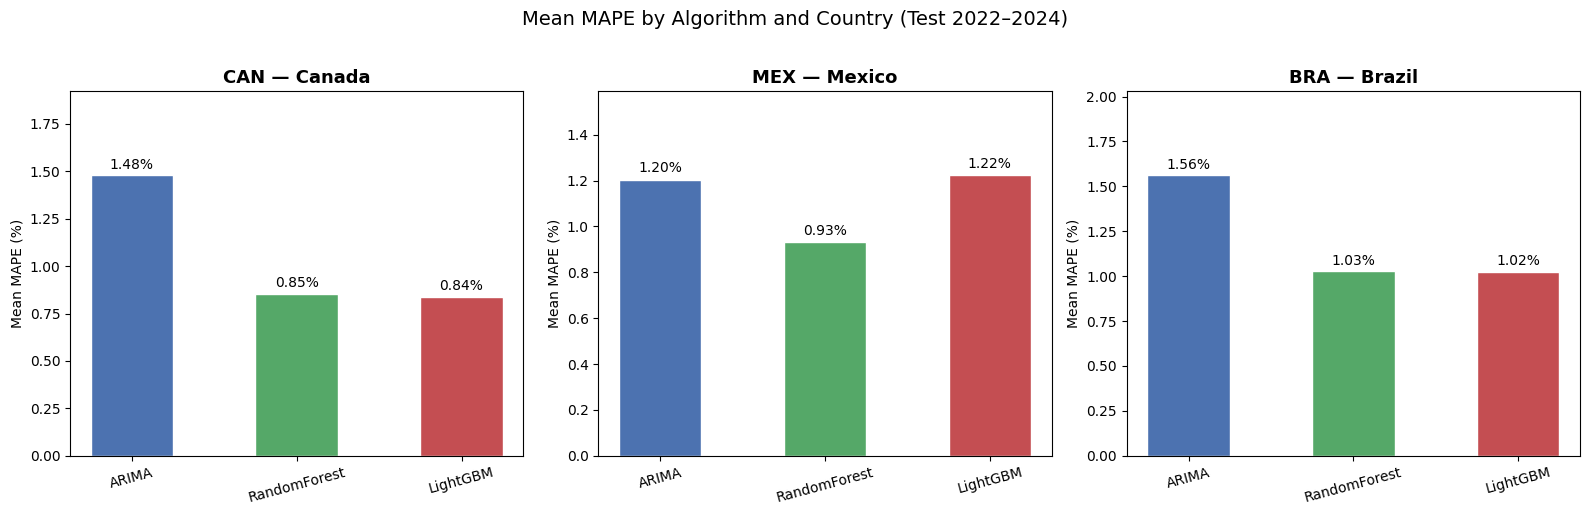

Saved: results/figures/mape_comparison.png


In [35]:
# --- MAPE comparison bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

algos   = ['ARIMA', 'RandomForest', 'LightGBM']
colors  = ['#4C72B0', '#55A868', '#C44E52']
countries = list(PARTNERS.keys())

for ax, iso in zip(axes, countries):
    vals = []
    for algo in algos:
        subset = df_all[(df_all['country'] == iso) & (df_all['algorithm'] == algo)]
        vals.append(subset['MAPE'].mean())

    bars = ax.bar(algos, vals, color=colors, width=0.5, edgecolor='white')
    ax.set_title(f'{iso} — {PARTNERS[iso]}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean MAPE (%)')
    ax.set_ylim(0, max(vals) * 1.3)
    ax.tick_params(axis='x', rotation=15)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

fig.suptitle('Mean MAPE by Algorithm and Country (Test 2022–2024)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'mape_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/mape_comparison.png')


In [36]:
# --- Actual vs Predicted plots (one figure per target, 3 algorithms) ---
FIGS_DIR = RESULTS / 'figures' / 'forecasts'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

algo_colors = {
    'ARIMA':        '#4C72B0',
    'RandomForest': '#55A868',
    'LightGBM':     '#C44E52',
}
forecast_stores = {
    'ARIMA':        arima_forecasts,
    'RandomForest': rf_forecasts,
    'LightGBM':     lgbm_forecasts,
}

for iso in PARTNERS:
    for target in TARGETS:
        fig, ax = plt.subplots(figsize=(12, 4))

        # Actual (same for all algorithms)
        ref = arima_forecasts[(iso, target)]
        ax.plot(ref['dates'], ref['y_true'],
                color='black', linewidth=1.8, label='Actual', zorder=5)

        for algo, store in forecast_stores.items():
            fc = store[(iso, target)]
            ax.plot(fc['dates'], fc['y_pred'],
                    color=algo_colors[algo], linewidth=1.2,
                    linestyle='--', alpha=0.85, label=algo)

        ax.set_title(f'{iso} — {target.replace("_", " ").title()} (log scale)',
                     fontsize=11)
        ax.set_ylabel('log trade value')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        plt.xticks(rotation=30)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        fname = FIGS_DIR / f'{iso.lower()}_{target}.png'
        plt.tight_layout()
        plt.savefig(fname, dpi=120, bbox_inches='tight')
        plt.close()

print(f'Saved {len(PARTNERS) * len(TARGETS)} forecast plots to results/figures/forecasts/')


Saved 24 forecast plots to results/figures/forecasts/


In [37]:
# --- Final ranking ---
summary = df_all.groupby('algorithm')[['MAE', 'RMSE', 'MAPE']].mean().round(4)
summary = summary.sort_values('MAPE')

print('=== Final Ranking (average across all 24 series) ===')
print()
print(summary.to_string())
print()

# Per-country ranking
print('=== MAPE by Algorithm x Country ===')
print()
pivot = df_all.groupby(['algorithm', 'country'])['MAPE'].mean().round(4).unstack()
print(pivot.to_string())
print()

# Best model per series
print('=== Best Algorithm per Target Series ===')
print()
best = df_all.loc[df_all.groupby(['country', 'target'])['MAPE'].idxmin(),
                  ['country', 'target', 'algorithm', 'MAPE']]
print(best.to_string(index=False))
print()
wins = best['algorithm'].value_counts()
print('Wins:')
for algo, n in wins.items():
    print(f'  {algo}: {n}/24')


=== Final Ranking (average across all 24 series) ===

                 MAE    RMSE    MAPE
algorithm                           
RandomForest  0.2122  0.2356  0.9381
LightGBM      0.2332  0.2534  1.0276
ARIMA         0.3185  0.3541  1.4143

=== MAPE by Algorithm x Country ===

country          BRA     CAN     MEX
algorithm                           
ARIMA         1.5606  1.4781  1.2042
LightGBM      1.0247  0.8362  1.2221
RandomForest  1.0282  0.8549  0.9312

=== Best Algorithm per Target Series ===

country                     target    algorithm   MAPE
    BRA        exports_commodities     LightGBM 0.8820
    BRA          exports_high-tech        ARIMA 0.5816
    BRA exports_manufactured_goods     LightGBM 0.6937
    BRA              exports_total     LightGBM 0.4767
    BRA        imports_commodities        ARIMA 0.6334
    BRA          imports_high-tech        ARIMA 0.5806
    BRA imports_manufactured_goods RandomForest 1.2345
    BRA              imports_total RandomForest 1.3938
